In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Câu 12:
Viết thuật toán hoặc vẽ sơ đồ khối cho phương pháp lặp đơn giải phương trình $x = \varphi(x)$ trên khoảng $(a, b)$ theo công thức sai số hậu nghiệm và tiên nghiệm với sai số cho trước.


## Thuật toán phương pháp lặp đơn

### Bài toán
Giải phương trình $x = \varphi(x)$ trên $[a, b]$ với sai số $\varepsilon$ cho trước.

### Điều kiện (Định lý 2.1)
- $|\varphi'(x)| \leq q < 1$, $\forall x \in [a, b]$
- $\varphi(x) \in [a, b]$, $\forall x \in [a, b]$

---

### Thuật toán (dùng sai số hậu nghiệm)

```
Input:  x0, ε, q      (điểm xuất phát, sai số, hằng số Lipschitz)
Output: x1            (nghiệm gần đúng)

BEGIN
  x1   ← φ(x0)
  err  ← |x1 - x0|

  WHILE err >= ε*(1-q)/q DO
      x0  ← x1
      x1  ← φ(x0)
      err ← |x1 - x0|
  END WHILE

  Print x1
END
```

---

### Thuật toán (dùng sai số tiên nghiệm)

```
Input:  x0, x1, ε, q
Output: x1

BEGIN
  WHILE q^n / (1-q) * |x1 - x0| >= ε DO
      x0 ← x1
      x1 ← φ(x0)
      n  ← n + 1
  END WHILE

  Print x1
END
```

> Thực tế thường dùng **sai số hậu nghiệm** vì không cần biết trước số bước $n$.

---

### Công thức dừng

| Loại sai số | Điều kiện dừng |
|---|---|
| Hậu nghiệm | $\|x_n - x_{n-1}\| < \varepsilon \cdot \dfrac{1-q}{q}$ |
| Tiên nghiệm | $\|x_n - \xi\| \leq \dfrac{q^n}{1-q}\|x_1 - x_0\| < \varepsilon$ |

---

### Sơ đồ khối

```
        [START]
           │
    [Input x₀, ε, q]
           │
    ┌──────▼──────────────────────┐
    │  x₁ = φ(x₀)                │◄──┐
    │  err = |x₁ - x₀|           │   │
    │  x₀ = x₁                   │   │
    └──────┬──────────────────────┘   │
           │                          │
    ┌──────▼──────────────┐          │
    │ err < ε(1-q)/q ?    │──no──────┘
    └──────┬──────────────┘
           │ yes
    [Print x₁]
           │
        [END]
```

# Câu 13:
Dùng phương pháp lặp đơn giải gần đúng các phương trình dưới đây với 8 chữ số đáng tin:

a. $x^3 + 3x^2 - 1 = 0$

b. $x^2 + 4\sin x - 1 = 0$

c. $1.4^x - x = 0$

d. $e^x - 10x + 7 = 0$

In [6]:
import math

def phi(x):
    # Thay hàm phi(x) tương ứng với bài toán
    # Ví dụ: x^3 + 3x^2 - 1 = 0  =>  phi(x) = 1/(x^2 + 3)
    return 1 / (x**2 + 3)

def lap_don(x0, eps, q):
    print(f"{'Bước':>5} | {'x_n':>20} | {'x_(n+1)':>20} | {'err':>20} | {'Ngưỡng':>20}")
    print("-" * 95)

    x1  = phi(x0)
    err = abs(x1 - x0)
    nguong = eps * (1 - q) / q
    n = 1

    print(f"{n:>5} | {x0:>20.10f} | {x1:>20.10f} | {err:>20.10e} | {nguong:>20.10e}")

    while err >= nguong:
        x0  = x1
        x1  = phi(x0)
        err = abs(x1 - x0)
        n  += 1
        print(f"{n:>5} | {x0:>20.10f} | {x1:>20.10f} | {err:>20.10e} | {nguong:>20.10e}")

    print("-" * 95)
    print(f"\nNghiệm gần đúng sau {n} bước lặp: x ≈ {x1:.10f}")
    print(f"   Sai số hậu nghiệm:  err = {err:.2e} < {nguong:.2e}")
    return x1

# ── Tham số đầu vào ──────────────────────────────
x0  = 0    # Điểm xuất phát
eps = 1e-8   # Sai số yêu cầu
q   = 0.2    # Hằng số Lipschitz (ước lượng max|phi'(x)|)
# ─────────────────────────────────────────────────

lap_don(x0, eps, q)

 Bước |                  x_n |              x_(n+1) |                  err |               Ngưỡng
-----------------------------------------------------------------------------------------------
    1 |         0.0000000000 |         0.3333333333 |     3.3333333333e-01 |     4.0000000000e-08
    2 |         0.3333333333 |         0.3214285714 |     1.1904761905e-02 |     4.0000000000e-08
    3 |         0.3214285714 |         0.3222359227 |     8.0735130057e-04 |     4.0000000000e-08
    4 |         0.3222359227 |         0.3221819720 |     5.3950725797e-05 |     4.0000000000e-08
    5 |         0.3221819720 |         0.3221855809 |     3.6088781503e-06 |     4.0000000000e-08
    6 |         0.3221855809 |         0.3221853395 |     2.4138915639e-07 |     4.0000000000e-08
    7 |         0.3221853395 |         0.3221853556 |     1.6146011639e-08 |     4.0000000000e-08
-----------------------------------------------------------------------------------------------

Nghiệm gần đúng sau 7 b

0.32218535563834977

*** 

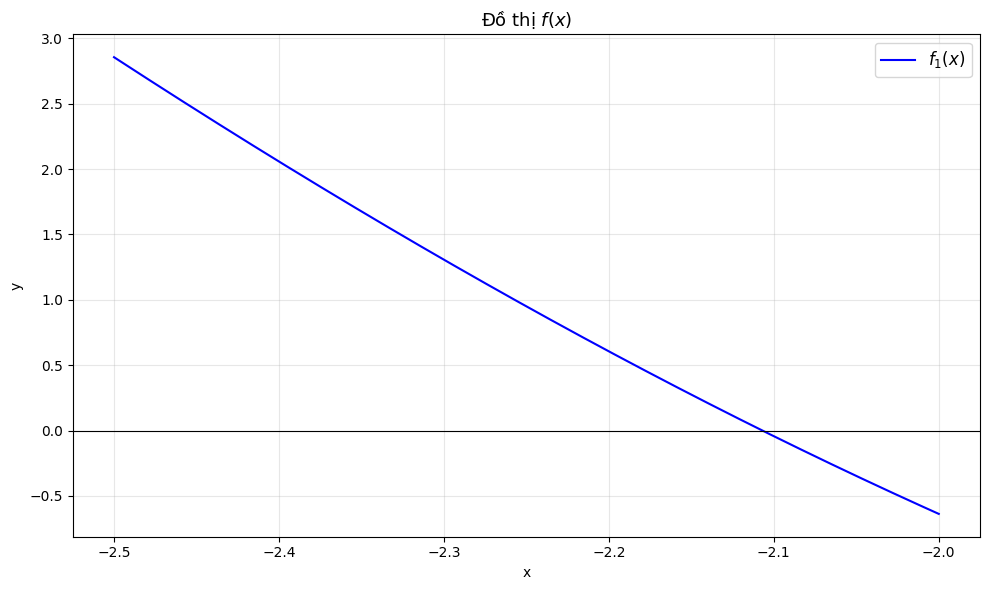

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===================== THAY ĐỔI Ở ĐÂY =====================
def f1(x):
    return x**2 + 4*np.sin(x) - 1          # hàm số 1

def f2(x):
    return None                    # hàm số 2 (xóa nếu không cần)

x_min, x_max = -2.5,-2             # khoảng x
# ===========================================================

x = np.linspace(x_min, x_max, 1000)

plt.figure(figsize=(10, 6))
plt.plot(x, f1(x), label=r'$f_1(x)$', color='blue', linewidth=1.5)
#plt.plot(x, f2(x), label=r'$f_2(x)$', color='red', linewidth=1.5)

# Đánh dấu giao điểm
# y = f1(x)
# sign_changes = np.where(np.diff(np.sign(y)))[0]
# for idx in sign_changes:
#     plt.axvline(x=x[idx], color='gray', linestyle='--', alpha=0.5)
#     plt.plot(x[idx], 0, 'ko', markersize=6)
#     plt.annotate(f'x ≈ {x[idx]:.4f}', xy=(x[idx], 0),
#                  xytext=(x[idx] + 0.01, 0.05), fontsize=9)

plt.axhline(0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.title(r'Đồ thị $f(x)$', fontsize=13)
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

In [7]:
import math

def phi(x):
    # Thay hàm phi(x) tương ứng với bài toán
    # Ví dụ: x^3 + 3x^2 - 1 = 0  =>  phi(x) = 1/(x^2 + 3)
    return x - (x**2 + 4*np.sin(x) - 1) / (2*x + 4*np.cos(x))

def lap_don(x0, eps, q):
    print(f"{'Bước':>5} | {'x_n':>20} | {'x_(n+1)':>20} | {'err':>20} | {'Ngưỡng':>20}")
    print("-" * 95)

    x1  = phi(x0)
    err = abs(x1 - x0)
    nguong = eps * (1 - q) / q
    n = 1

    print(f"{n:>5} | {x0:>20.10f} | {x1:>20.10f} | {err:>20.10f} | {nguong:>20.10f}")

    while err >= nguong:
        x0  = x1
        x1  = phi(x0)
        err = abs(x1 - x0)
        n  += 1
        print(f"{n:>5} | {x0:>20.10f} | {x1:>20.10f} | {err:>20.10f} | {nguong:>20.10f}")

    print("-" * 95)
    print(f"\nNghiệm gần đúng sau {n} bước lặp: x ≈ {x1:.10f}")
    print(f"   Sai số hậu nghiệm:  err = {err:.10f} < {nguong:.10f}")
    return x1

# ── Tham số đầu vào ──────────────────────────────
x0  = -3    # Điểm xuất phát
eps = 1/2*10**(-8)   # Sai số yêu cầu
q   = 0.3    # Hằng số Lipschitz (ước lượng max|phi'(x)|)
# ─────────────────────────────────────────────────

lap_don(x0, eps, q)

 Bước |                  x_n |              x_(n+1) |                  err |               Ngưỡng
-----------------------------------------------------------------------------------------------
    1 |        -3.0000000000 |        -2.2534596010 |         0.7465403990 |         0.0000000117
    2 |        -2.2534596010 |        -2.1148467714 |         0.1386128296 |         0.0000000117
    3 |        -2.1148467714 |        -2.1068945097 |         0.0079522617 |         0.0000000117
    4 |        -2.1068945097 |        -2.1068670798 |         0.0000274300 |         0.0000000117
    5 |        -2.1068670798 |        -2.1068670794 |         0.0000000003 |         0.0000000117
-----------------------------------------------------------------------------------------------

Nghiệm gần đúng sau 5 bước lặp: x ≈ -2.1068670794
   Sai số hậu nghiệm:  err = 0.0000000003 < 0.0000000117


np.float64(-2.106867079425129)

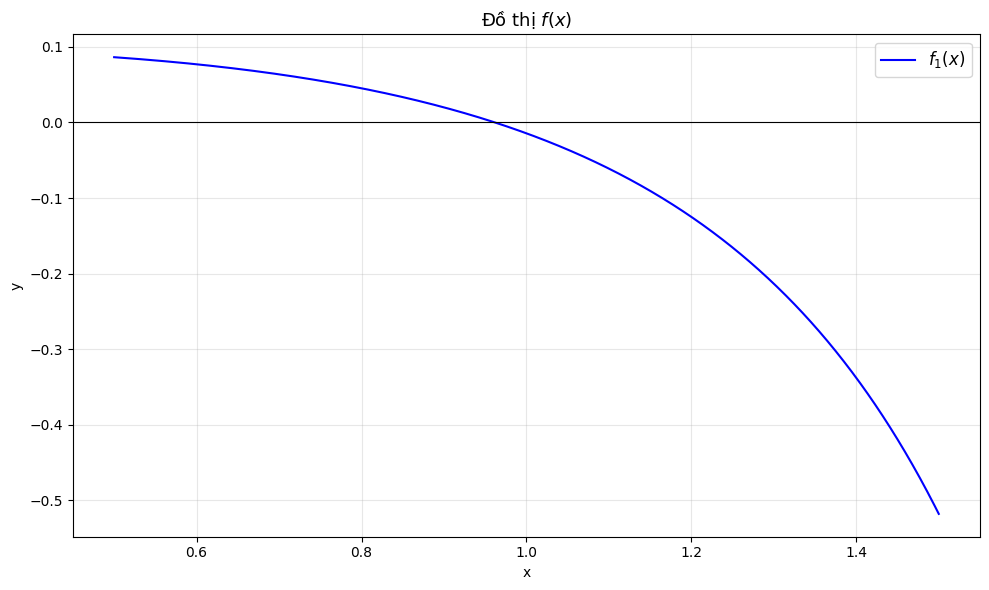

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ===================== THAY ĐỔI Ở ĐÂY =====================
def f1(x):
    return (np.exp(2*x) - 10*x*np.exp(x) + 7*np.exp(x)) / (np.exp(x) - 10)**2         # hàm số 1

def f2(x):
    return None                    # hàm số 2 (xóa nếu không cần)

x_min, x_max = 0.5,1.5             # khoảng x
# ===========================================================

x = np.linspace(x_min, x_max, 1000)

plt.figure(figsize=(10, 6))
plt.plot(x, f1(x), label=r'$f_1(x)$', color='blue', linewidth=1.5)
#plt.plot(x, f2(x), label=r'$f_2(x)$', color='red', linewidth=1.5)

# Đánh dấu giao điểm
# y = f1(x)
# sign_changes = np.where(np.diff(np.sign(y)))[0]
# for idx in sign_changes:
#     plt.axvline(x=x[idx], color='gray', linestyle='--', alpha=0.5)
#     plt.plot(x[idx], 0, 'ko', markersize=6)
#     plt.annotate(f'x ≈ {x[idx]:.4f}', xy=(x[idx], 0),
#                  xytext=(x[idx] + 0.01, 0.05), fontsize=9)

plt.axhline(0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.title(r'Đồ thị $f(x)$', fontsize=13)
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

In [21]:
import math

def phi(x):
    # Thay hàm phi(x) tương ứng với bài toán
    # Ví dụ: x^3 + 3x^2 - 1 = 0  =>  phi(x) = 1/(x^2 + 3)
    return x - (np.exp(x) - 10*x + 7) / (np.exp(x) - 10)

def lap_don(x0, eps, q):
    print(f"{'Bước':>5} | {'x_n':>20} | {'x_(n+1)':>20} | {'err':>20} | {'Ngưỡng':>20}")
    print("-" * 95)

    x1  = phi(x0)
    err = abs(x1 - x0)
    nguong = eps * (1 - q) / q
    n = 1

    print(f"{n:>5} | {x0:>20.10f} | {x1:>20.10f} | {err:>20.10f} | {nguong:>20.10f}")

    while err >= nguong:
        x0  = x1
        x1  = phi(x0)
        err = abs(x1 - x0)
        n  += 1
        print(f"{n:>5} | {x0:>20.10f} | {x1:>20.10f} | {err:>20.10f} | {nguong:>20.10f}")

    print("-" * 95)
    print(f"\nNghiệm gần đúng sau {n} bước lặp: x ≈ {x1:.10f}")
    print(f"   Sai số hậu nghiệm:  err = {err:.10f} < {nguong:.10f}")
    return x1

# ── Tham số đầu vào ──────────────────────────────
x0  = 0.5   # Điểm xuất phát
eps = 1/2*10**(-8)   # Sai số yêu cầu
q   = 0.5    # Hằng số Lipschitz (ước lượng max|phi'(x)|)
# ─────────────────────────────────────────────────

lap_don(x0, eps, q)

 Bước |                  x_n |              x_(n+1) |                  err |               Ngưỡng
-----------------------------------------------------------------------------------------------
    1 |         0.5000000000 |         0.9369056990 |         0.4369056990 |         0.0000000050
    2 |         0.9369056990 |         0.9614783487 |         0.0245726497 |         0.0000000050
    3 |         0.9614783487 |         0.9615835483 |         0.0001051996 |         0.0000000050
    4 |         0.9615835483 |         0.9615835502 |         0.0000000020 |         0.0000000050
-----------------------------------------------------------------------------------------------

Nghiệm gần đúng sau 4 bước lặp: x ≈ 0.9615835502
   Sai số hậu nghiệm:  err = 0.0000000020 < 0.0000000050


np.float64(0.9615835502285679)

***

# Câu 14:
Theo định luật Archimedes, độ lớn của lực đẩy tác động lên vật thả trong chất lỏng được tính bằng trọng lượng của phần chất lỏng bị chiếm chỗ bởi vật $F_A = V\rho_N g$. Trong Hình 2, vật thả trong nước có hình cầu bán kính $r = 1$ m, khối lượng riêng của vật là $\rho_S = 201 \text{ kg/m}^3$, và khối lượng riêng của nước là $\rho_N = 1000 \text{ kg/m}^3$. Hãy dùng phương pháp chia đôi xác định khoảng cách $h$ từ bề mặt chất lỏng đến hình cầu.
